In [18]:
import os
import sys
sys.path.append("../") # go to parent dir
%load_ext autoreload
%autoreload 2
# Import libraries
import pandas as pd
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import cv2
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
import multiprocessing
import numpy as np
from PIL import Image

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plant Disease Symptoms: CSSVD and Anthracnose

## Cocoa Swollen Shoot Virus Disease (CSSVD)

CSSVD is a serious viral disease affecting cocoa trees (*Theobroma cacao*), primarily in West Africa.

### Symptoms

- **Stem swelling**: Characteristic swellings on stems and branches
- **Red vein banding**: Reddening of the leaf veins, particularly in young leaves
- **Leaf chlorosis**: Yellow patterns between leaf veins creating a "fern-like" pattern
- **Leaf size reduction**: Smaller leaves than healthy plants
- **Pod deformation**: Smaller pods with reduced bean count and quality
- **Dieback**: Progressive death of branches from the tips inward
- **Yield reduction**: Can reduce yields by 25-70% depending on strain severity
- **Tree death**: Complete death of the tree within 2-5 years in severe cases

### Transmission

- Primarily spread by mealybugs (*Planococcoides njalensis* and others)
- Can also spread through infected plant material used for propagation

## Anthracnose

Anthracnose refers to a group of fungal diseases affecting many plant species, caused primarily by fungi in the genus *Colletotrichum*.

### Symptoms

- **Leaf spots**: Dark, water-soaked lesions that expand into irregular shapes
- **Sunken lesions**: Characteristic sunken, dark lesions on fruits, stems, and leaves
- **Necrotic tissue**: Dead, brown or black tissue, often with a target-like appearance
- **Lesion centers**: Centers of lesions may turn tan or gray as they age
- **Salmon-colored spore masses**: Pink to orange spore masses may appear in the center of lesions during humid conditions
- **Leaf veins**: Lesions often follow leaf veins, creating a angular appearance
- **Leaf curl**: Infected leaves may curl or become distorted
- **Premature defoliation**: Heavy infections can cause early leaf drop
- **Fruit rot**: Circular, sunken, dark lesions on fruits that may expand and cause rot
- **Twig dieback**: Death of young shoots and twigs from the tip backward

### Conditions Favoring Anthracnose

- High humidity and rainfall
- Moderate to warm temperatures (68-86°F/20-30°C)
- Poor air circulation
- Overhead irrigation that keeps foliage wet
- Overcrowded plantings

### Common Plants Affected by Anthracnose

- Trees: Oak, maple, ash, sycamore, dogwood
- Fruits: Mango, banana, avocado, citrus, strawberry, grape
- Vegetables: Tomato, pepper, cucumber, bean
- Ornamentals: Rose, hydrangea, zinnia

### Management Practices for Both Diseases

- Use resistant varieties when available
- Remove and destroy infected plant material
- Ensure proper spacing for adequate air circulation
- Apply appropriate fungicides (for anthracnose) or vector control (for CSSVD)
- Practice good sanitation in the garden or field
- Avoid overhead irrigation (for anthracnose)
- Use certified disease-free planting material

In [25]:
from functions.loading_functions import *

In [31]:
# Load train and test files
train = get_dataset("train")
test = get_dataset("test")

display(train.head())
display(test.head())


,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg


,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_Genxyu.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/test/ID_Genxyu.jpg
1,ID_svY6TG.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/test/ID_svY6TG.jpg
2,ID_d0gpda.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/test/ID_d0gpda.jpg
3,ID_frWmBT.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/test/ID_frWmBT.jpg
4,ID_TaRW6o.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/test/ID_TaRW6o.jpg


In [39]:
train

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg
...,...,...,...,...,...,...,...,...,...
9787,ID_WULBQy.jpeg,anthracnose,1.0,136.0,1440.0,1593.0,4000.0,0,dataset/images/train/ID_WULBQy.jpeg
9788,ID_WULBQy.jpeg,anthracnose,1.0,89.0,0.0,1174.0,1139.0,0,dataset/images/train/ID_WULBQy.jpeg
9789,ID_SVzl5X.jpeg,anthracnose,1.0,18.0,360.0,1800.0,2330.0,0,dataset/images/train/ID_SVzl5X.jpeg
9790,ID_xDTIEp.jpeg,anthracnose,1.0,736.0,174.0,2691.0,4032.0,0,dataset/images/train/ID_xDTIEp.jpeg


In [37]:
train.columns


Index(['Image_ID', 'class', 'confidence', 'ymin', 'xmin', 'ymax', 'xmax',
       'class_id', 'ImagePath'],
      dtype='object')

In [34]:
# Split the train dataset into train_df & val_df
train_names, val_names = train_test_split(train['Image_ID'].unique(), test_size=0.15, random_state=42)

train_df = train[train['Image_ID'].isin(train_names)]
val_df = train[train['Image_ID'].isin(val_names)]

In [26]:
# The correct mapping from class to class_id
class_map = {cls: i for i, cls in enumerate(sorted(train['class'].unique().tolist()))}

# Map it
train['class_id'] = train['class'].map(class_map)

# Check
display(train[['class', 'class_id']].value_counts())

class        class_id
healthy      2           4280
cssvd        1           3241
anthracnose  0           2271
Name: count, dtype: int64

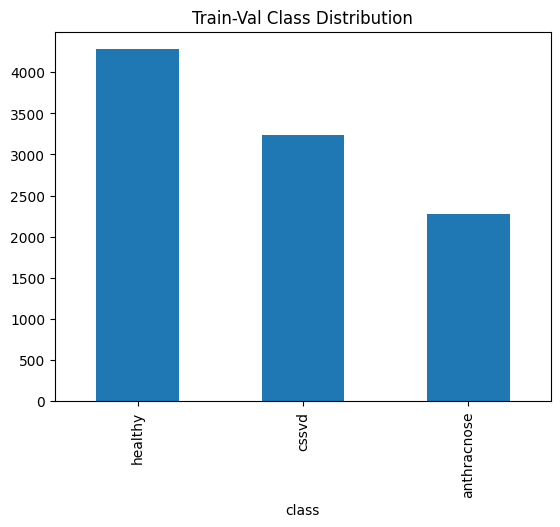

In [27]:
train['class'].value_counts().plot(kind='bar')
plt.title('Train-Val Class Distribution')
plt.show()

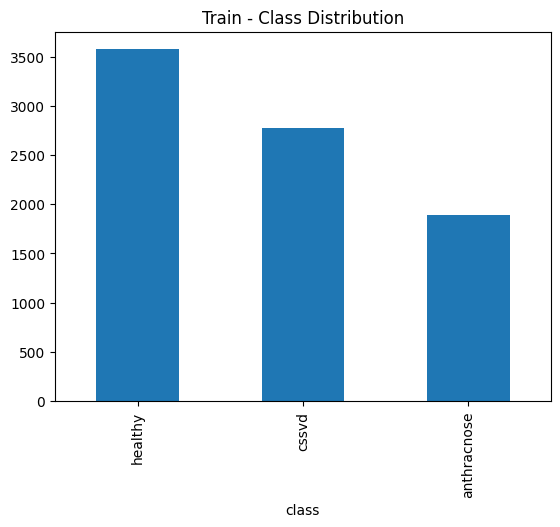

In [28]:
train_df['class'].value_counts().plot(kind='bar')
plt.title('Train - Class Distribution')
plt.show();

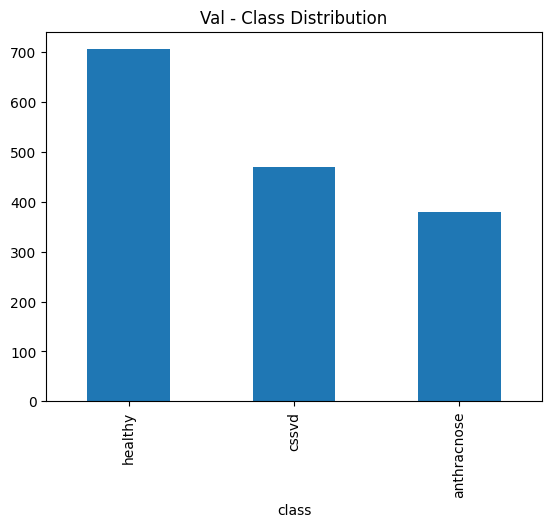

In [29]:
val_df['class'].value_counts().plot(kind='bar')
plt.title('Val - Class Distribution')
plt.show();

## Mobile-Friendly Machine Learning Model for Cocoa Leaf Disease Identification - Pre-trained Model Recommendations

Based on the requirements of your mobile-friendly cocoa leaf disease identification project, here's a breakdown of suitable pre-trained models, focusing on efficiency, generalization, and mobile deployment:

**Key Considerations:**

* **Mobile Efficiency:** The models must be lightweight and fast for deployment on resource-constrained devices.
* **Generalization:** The model needs to handle unseen diseases, indicating a need for robust feature extraction.
* **Object Detection:** The training data includes bounding boxes, so an object detection architecture is required.
* **Transfer Learning:** Pre-trained models are crucial for fast development and good performance with limited data.

**Recommended Pre-trained Models:**

1.  **MobileNetV2/V3:**
    * **Why:** These models are specifically designed for mobile devices. They offer a good balance between accuracy and speed. They have proven to be very effective in image classification and object detection tasks.
    * **Use with:**
        * **SSD (Single Shot MultiBox Detector):** A lightweight object detection architecture that works well with MobileNet backbones.
        * **YOLOv5/YOLOv8-Nano/Mobile:** The YOLO family has very efficient versions that are great for mobile. The nano and mobile versions are designed for edge devices.
    * **Advantages:** Very fast inference, small model size.

2.  **EfficientNet-Lite:**
    * **Why:** Google's EfficientNet models are known for their high accuracy. The "Lite" versions are optimized for mobile devices.
    * **Use with:**
        * **EfficientDet-Lite:** Designed to work in conjuction with the efficient net model.
    * **Advantages:** Excellent accuracy while remaining relatively efficient.

3.  **Tiny-YOLO (YOLOv3-Tiny, YOLOv4-Tiny):**
    * **Why:** These models are designed for real-time object detection on low-resource devices.
    * **Advantages:** Extremely fast inference, very small model size.
    * **Disadvantages:** Lower accuracy compared to larger models, but may be sufficient for this task.

4.  **ResNet-18/ResNet-34 (with pruning/quantization):**
    * **Why:** ResNet models are powerful feature extractors. You can make them mobile-friendly through techniques like pruning and quantization.
    * **Use with:**
        * **Faster R-CNN (with modifications):** While Faster R-CNN is typically heavy, it can be adapted for mobile with a lighter backbone (ResNet-18) and optimization.
    * **Advantages:** Strong feature extraction, well-established architecture.
    * **Disadvantages:** Requires significant optimization for mobile deployment.

**Strategies for Generalization and Mobile Deployment:**

* **Data Augmentation:** Apply extensive data augmentation techniques (e.g., rotations, flips, color jittering) to improve generalization.
* **Transfer Learning with Fine-Tuning:** Use the pre-trained models as feature extractors and fine-tune them on your cocoa leaf disease dataset. Pay special attention to the last few layers to adapt to the specific diseases.
* **Knowledge Distillation:** Train a smaller, mobile-friendly model to mimic the behavior of a larger, more accurate model.
* **Model Quantization:** Convert the model's weights to lower precision (e.g., 8-bit integers) to reduce model size and improve inference speed.
* **Model Pruning:** Remove redundant connections in the neural network to reduce model size and improve efficiency.
* **TensorFlow Lite or ONNX Runtime:** Use these frameworks to optimize and deploy your models on mobile devices.
* **Edge TPU (If Available):** If the target devices have Edge TPUs, consider using them for accelerated inference.

**Workflow:**

1.  **Choose a Model:** Start with MobileNetV2/V3 or EfficientNet-Lite, as they are well-suited for mobile.
2.  **Adapt for Object Detection:** Integrate the chosen model with an SSD or YOLO architecture.
3.  **Fine-Tune:** Fine-tune the model on your cocoa leaf disease dataset.
4.  **Optimize:** Apply quantization, pruning, and other optimization techniques.
5.  **Deploy:** Deploy the optimized model using TensorFlow Lite or ONNX Runtime.

By following these recommendations, you can develop a mobile-friendly machine learning model that accurately identifies cocoa leaf diseases and empowers farmers with real-time diagnostics.

In [31]:
train.columns

Index(['Image_ID', 'class', 'confidence', 'ymin', 'xmin', 'ymax', 'xmax',
       'class_id', 'ImagePath'],
      dtype='object')

In [109]:
path_to_explore = os.path.join(os.getcwd(), 'dataset', 'images')

In [99]:
train_df

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg
...,...,...,...,...,...,...,...,...,...
9787,ID_WULBQy.jpeg,anthracnose,1.0,136.0,1440.0,1593.0,4000.0,0,dataset/images/train/ID_WULBQy.jpeg
9788,ID_WULBQy.jpeg,anthracnose,1.0,89.0,0.0,1174.0,1139.0,0,dataset/images/train/ID_WULBQy.jpeg
9789,ID_SVzl5X.jpeg,anthracnose,1.0,18.0,360.0,1800.0,2330.0,0,dataset/images/train/ID_SVzl5X.jpeg
9790,ID_xDTIEp.jpeg,anthracnose,1.0,736.0,174.0,2691.0,4032.0,0,dataset/images/train/ID_xDTIEp.jpeg


In [110]:
import pandas as pd

def merge_paths(base_path, relative_path):
    return base_path.replace('dataset/images', '') + relative_path

# Assuming train_df and path_to_explore are defined

train_df['ImagePath'] = train_df['ImagePath'].copy() # create a copy of the column.
train_df['ImagePath'] = [merge_paths(path_to_explore, x) for x in train_df['ImagePath']]

/var/folders/z5/0zcty47158z_6yrxhg6qtbrc0000gn/T/ipykernel_24954/851227852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['ImagePath'] = train_df['ImagePath'].copy() # create a copy of the column.
/var/folders/z5/0zcty47158z_6yrxhg6qtbrc0000gn/T/ipykernel_24954/851227852.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['ImagePath'] = [merge_paths(path_to_explore, x) for x in train_df['ImagePath']]


In [111]:
train_df.loc[0].to_dict()

{'Image_ID': 'ID_nBgcAR.jpg',
 'class': 'healthy',
 'confidence': 1.0,
 'ymin': 75.0,
 'xmin': 15.0,
 'ymax': 162.0,
 'xmax': 195.0,
 'class_id': 2,
 'ImagePath': '/Users/jasonplymenos/Documents/aueb/deep learning/amini_cocoa_contamination/dataset/images/train/ID_nBgcAR.jpg'}

In [118]:
train_df['class'].unique()

array(['healthy', 'anthracnose', 'cssvd'], dtype=object)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

def plot_image_with_boxes_from_dict(image_dict):
    """Plots an image with a bounding box from a dictionary, with class-specific colors."""

    image_path = image_dict['ImagePath']
    image = np.array(Image.open(str(image_path)))
    h, w, _ = image.shape

    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    xmin = int(image_dict['xmin'])
    ymin = int(image_dict['ymin'])
    xmax = int(image_dict['xmax'])
    ymax = int(image_dict['ymax'])
    class_name = image_dict['class']  # Get class name

    # Define class-specific colors
    class_colors = {
        'healthy': 'green',       # Green for healthy
        'anthracnose': 'red',     # Red for anthracnose
        'cssvd': 'blue'          # Blue for cssvd
    }

    color = class_colors.get(class_name, 'black')  # Default to black if class not found

    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                      edgecolor=color, facecolor='none', linewidth=2))
    plt.text(xmin, ymin - 10, f'{class_name}', color=color, fontsize=8, weight='bold')

    plt.axis('off')
    plt.show()

In [36]:
train_df

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg
...,...,...,...,...,...,...,...,...,...
9787,ID_WULBQy.jpeg,anthracnose,1.0,136.0,1440.0,1593.0,4000.0,0,dataset/images/train/ID_WULBQy.jpeg
9788,ID_WULBQy.jpeg,anthracnose,1.0,89.0,0.0,1174.0,1139.0,0,dataset/images/train/ID_WULBQy.jpeg
9789,ID_SVzl5X.jpeg,anthracnose,1.0,18.0,360.0,1800.0,2330.0,0,dataset/images/train/ID_SVzl5X.jpeg
9790,ID_xDTIEp.jpeg,anthracnose,1.0,736.0,174.0,2691.0,4032.0,0,dataset/images/train/ID_xDTIEp.jpeg


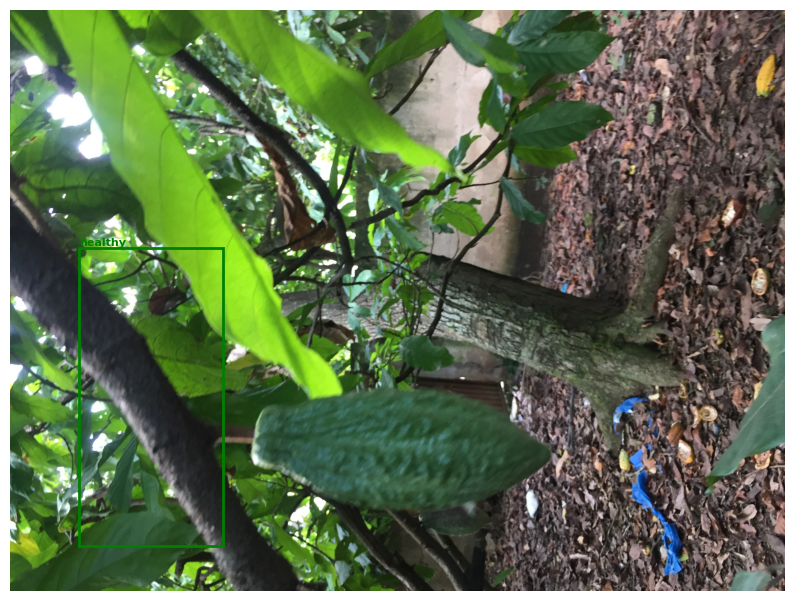

In [35]:
# Select random row from train_df
random_idx = random.randint(0, train_df.shape[0] - 1)
plot_image_with_boxes_from_dict(train_df.loc[random_idx].to_dict())

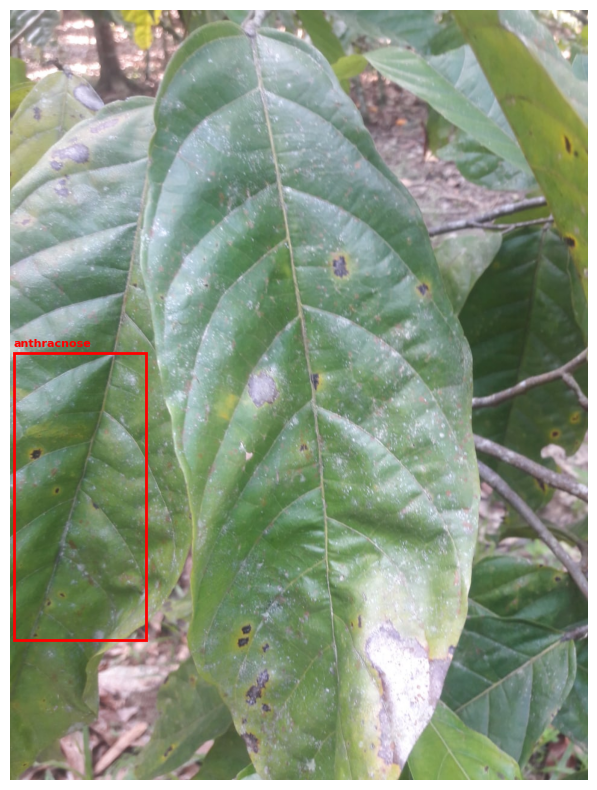

In [126]:
# Select random row from train_df
random_idx = random.randint(0, train_df.shape[0] - 1)
plot_image_with_boxes_from_dict(train_df.loc[random_idx].to_dict())

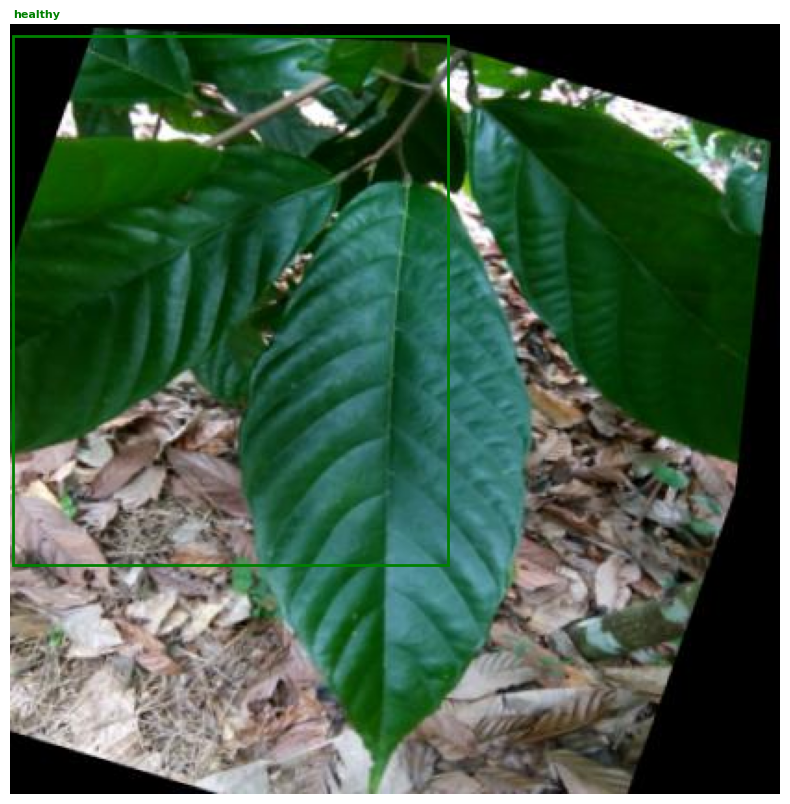

In [127]:
# Select random row from train_df
random_idx = random.randint(0, train_df.shape[0] - 1)
plot_image_with_boxes_from_dict(train_df.loc[random_idx].to_dict())

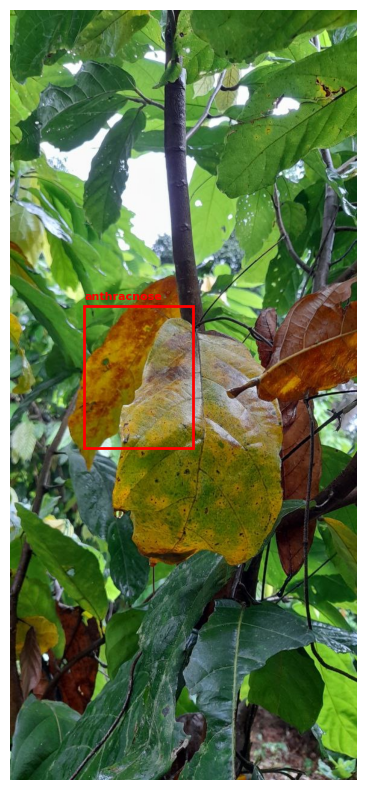

In [148]:
# Select random row from train_df
random_idx = random.sample(train_df.index.tolist(), 1)[0]
plot_image_with_boxes_from_dict(train_df.loc[random_idx].to_dict())